## **Step 1** — Install Dependencies & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers>=4.37 accelerate timm xformers
!pip install -q torch torchvision
!pip install -q opencv-python-headless albumentations
!pip install -q matplotlib tqdm scikit-learn
print('✅ Dependencies installed')

Mounted at /content/drive
✅ Dependencies installed


## Step 2 — Imports & Global Config

In [2]:
import os, cv2, numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from transformers import SegformerForSemanticSegmentation

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Step 3 — Paths & Class Definitions

In [3]:
# ── Dataset paths ────────────────────────────────────────────────────────────
DRIVE_ROOT    = '/content/drive/MyDrive/CVRoadMarkDetection/dataset'
VALID_IMG_DIR = os.path.join(DRIVE_ROOT, 'valid/images')
VALID_LBL_DIR = os.path.join(DRIVE_ROOT, 'valid/labels')
TEST_IMG_DIR  = os.path.join(DRIVE_ROOT, 'test/images')
TEST_LBL_DIR  = os.path.join(DRIVE_ROOT, 'test/labels')

# ── Pre-converted mask directories (from your earlier training runs) ──────────
SEGFORMER_MASK_DIR  = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/masks'
DEEPLAB_MASK_DIR    = '/content/drive/MyDrive/CVRoadMarkDetection/SegFormer/masks'

# ── Checkpoints ──────────────────────────────────────────────────────────────
SEGFORMER_CKPT = '/content/drive/MyDrive/CVRoadMarkDetection/BestModels/segformer_best.pth'
DEEPLAB_CKPT   = '/content/drive/MyDrive/CVRoadMarkDetection/BestModels/deeplab_best.pth'

# ── Output directory for ensemble results ────────────────────────────────────
ENSEMBLE_OUT   = '/content/drive/MyDrive/CVRoadMarkDetection/Ensemble'
os.makedirs(ENSEMBLE_OUT, exist_ok=True)

# ── Class definitions (0 = background) ───────────────────────────────────────
CLASS_NAMES = [
    'background',
    'BUS LANE', 'Yellow Markings', 'Line 1', 'Line 2',
    'Crossing', 'Romb', 'SLOW', 'Left Arrow',
    'Forward Arrow', 'Forward Arrow -Left', 'Forward Arrow -Right',
    'Right Arrow', 'Bicycle'
]
NUM_CLASSES = len(CLASS_NAMES)   # 14 (background + 13)
IMG_SIZE    = 512
BATCH_SIZE  = 4

print(f'NUM_CLASSES={NUM_CLASSES}  IMG_SIZE={IMG_SIZE}')

NUM_CLASSES=14  IMG_SIZE=512


## Step 4 — Dataset & DataLoaders

In [4]:
val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class RoadMarkDataset(Dataset):
    """Loads (image, mask) pairs. Masks must be PNG files with pixel values = class id."""
    def __init__(self, img_dir, mask_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for ext in ['*.jpg','*.jpeg','*.png','*.JPG']:
            for ip in sorted(Path(img_dir).glob(ext)):
                mp = Path(mask_dir) / (ip.stem + '.png')
                if mp.exists():
                    self.samples.append((ip, mp))
        print(f'  {len(self.samples)} samples  [{img_dir}]')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        image  = np.array(Image.open(ip).convert('RGB'))
        mask   = np.array(Image.open(mp))
        if self.transform:
            a = self.transform(image=image, mask=mask)
            image, mask = a['image'], a['mask']
        return image.float(), mask.long(), str(ip.stem)


MASK_DIR = SEGFORMER_MASK_DIR   # both models share the same ground-truth masks
NUM_WORKERS = min(2, os.cpu_count())

val_ds   = RoadMarkDataset(VALID_IMG_DIR, MASK_DIR+'/valid', val_tf)
test_ds  = RoadMarkDataset(TEST_IMG_DIR,  MASK_DIR+'/test',  val_tf)

val_loader  = DataLoader(val_ds,  BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders ready.')

  417 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/valid/images]
  192 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/test/images]
DataLoaders ready.


## Step 5 — Define & Load SegFormer

In [5]:
id2label = {i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}
label2id = {v: k for k, v in id2label.items()}

segformer = SegformerForSemanticSegmentation.from_pretrained(
    'nvidia/mit-b3',
    num_labels              = NUM_CLASSES,
    id2label                = id2label,
    label2id                = label2id,
    ignore_mismatched_sizes = True
).to(DEVICE)

sf_ckpt = torch.load(SEGFORMER_CKPT, map_location=DEVICE, weights_only=False)
sf_state = sf_ckpt.get('model_state_dict', sf_ckpt)
segformer.load_state_dict(sf_state, strict=False)
segformer.eval()

print('✅ SegFormer loaded')

def segformer_logits(model, imgs):
    """Returns logits [B, C, H, W] upsampled to input resolution."""
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            raw = model(pixel_values=imgs).logits   # [B, C, H/4, W/4]
    return F.interpolate(raw, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/628 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b3
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

✅ SegFormer loaded


## Step 6 — Define & Load DeepLabV3+

In [6]:
class ASPPConv(nn.Sequential):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

class ASPPPooling(nn.Sequential):
    def __init__(self, in_ch, out_ch):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        size = x.shape[-2:]
        for m in self: x = m(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ASPP(nn.Module):
    def __init__(self, in_ch=2048, out_ch=256, rates=(6, 12, 18)):
        super().__init__()
        mods = [nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 1, bias=False),
                    nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))]
        for r in rates:
            mods.append(ASPPConv(in_ch, out_ch, r))
        mods.append(ASPPPooling(in_ch, out_ch))
        self.convs = nn.ModuleList(mods)
        self.project = nn.Sequential(
            nn.Conv2d(len(mods) * out_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.project(torch.cat([c(x) for c in self.convs], dim=1))

class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        bb = tv_models.resnet101(weights='IMAGENET1K_V2' if pretrained else None)

        self.layer0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1   # 256 ch, stride 4
        self.layer2 = bb.layer2   # 512 ch, stride 8
        self.layer3 = bb.layer3   # 1024 ch
        self.layer4 = bb.layer4   # 2048 ch

        # Apply dilated convolutions to layer3 & layer4 (output stride = 16)
        for n, m in self.layer3.named_modules():
            if 'conv2' in n:
                m.dilation = (2, 2); m.padding = (2, 2)
        for n, m in self.layer4.named_modules():
            if 'conv2' in n:
                m.dilation = (4, 4); m.padding = (4, 4)

        self.aspp = ASPP(2048, 256, (6, 12, 18))

        self.low_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.1),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        in_size   = x.shape[-2:]
        x         = self.layer0(x)
        low       = self.layer1(x)
        x         = self.layer2(low)
        x         = self.layer3(x)
        x         = self.layer4(x)
        x         = self.aspp(x)
        x         = F.interpolate(x, size=low.shape[-2:], mode='bilinear', align_corners=False)
        low       = self.low_proj(low)
        x         = self.decoder(torch.cat([x, low], dim=1))
        return F.interpolate(x, size=in_size, mode='bilinear', align_corners=False)

deeplab = DeepLabV3Plus(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
dl_ckpt  = torch.load(DEEPLAB_CKPT, map_location=DEVICE, weights_only=False)
dl_state = dl_ckpt.get('model_state_dict', dl_ckpt)
deeplab.load_state_dict(dl_state, strict=False)
deeplab.eval()

print('✅ DeepLabV3+ loaded')

def deeplab_logits(model, imgs):
    """Returns logits [B, C, H, W]."""
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            return model(imgs)

✅ DeepLabV3+ loaded


## Step 7 — Per-Class IoU Helper

In [7]:
def compute_per_class_iou(preds, targets, n_cls):
    """
    preds, targets : LongTensors of shape [B, H, W]
    Returns: numpy array of shape [n_cls]  (NaN if class absent)
    """
    ious = np.full(n_cls, np.nan)
    for c in range(n_cls):
        p = (preds == c)
        t = (targets == c)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0:
            ious[c] = inter / union
    return ious


def evaluate_model(get_logits_fn, loader, n_cls, tag):
    """
    Runs `get_logits_fn(imgs)` for every batch, accumulates
    intersection and union counts per class.

    Returns:
        class_iou   : np.array [n_cls]   per-class IoU
        miou        : float              mean IoU (ignores NaN)
    """
    inter_sum = np.zeros(n_cls, dtype=np.float64)
    union_sum = np.zeros(n_cls, dtype=np.float64)

    for imgs, masks, _ in tqdm(loader, desc=f'Eval {tag}'):
        imgs  = imgs.to(DEVICE)
        masks = masks.cpu()
        logits = get_logits_fn(imgs).cpu()
        preds  = logits.argmax(1)       # [B, H, W]

        for c in range(n_cls):
            p = (preds == c)
            t = (masks == c)
            inter_sum[c] += (p & t).sum().item()
            union_sum[c] += (p | t).sum().item()

    class_iou = np.where(union_sum > 0, inter_sum / union_sum, np.nan)
    miou = float(np.nanmean(class_iou))
    print(f'  [{tag}]  mIoU = {miou:.4f}')
    return class_iou, miou

print('Helper defined ✅')

Helper defined ✅


## Step 8 — Calibrate on Validation Set

Run both models on the **validation set** to determine, per class, which model is stronger.

In [8]:
print('=== Calibrating on validation set ===')

sf_val_iou, sf_val_miou = evaluate_model(
    lambda imgs: segformer_logits(segformer, imgs),
    val_loader, NUM_CLASSES, 'SegFormer'
)

dl_val_iou, dl_val_miou = evaluate_model(
    lambda imgs: deeplab_logits(deeplab, imgs),
    val_loader, NUM_CLASSES, 'DeepLabV3+'
)

# ── Print per-class comparison ─────────────────────────────────────────────────
print(f'\n{"Class":<28} {"SegFormer":>10} {"DeepLab":>10} {"Winner":>12}')
print('-' * 65)
for c in range(NUM_CLASSES):
    sf_v = sf_val_iou[c]
    dl_v = dl_val_iou[c]
    if np.isnan(sf_v) and np.isnan(dl_v):
        winner = 'absent'
    elif np.isnan(sf_v):
        winner = 'DeepLab'
    elif np.isnan(dl_v):
        winner = 'SegFormer'
    else:
        winner = 'SegFormer' if sf_v >= dl_v else 'DeepLab'
    sf_s = f'{sf_v:.4f}' if not np.isnan(sf_v) else '  N/A '
    dl_s = f'{dl_v:.4f}' if not np.isnan(dl_v) else '  N/A '
    print(f'{CLASS_NAMES[c]:<28} {sf_s:>10} {dl_s:>10} {winner:>12}')

print(f'\nVal mIoU — SegFormer: {sf_val_miou:.4f}   DeepLabV3+: {dl_val_miou:.4f}')

=== Calibrating on validation set ===


Eval SegFormer: 100%|██████████| 105/105 [03:10<00:00,  1.81s/it]


  [SegFormer]  mIoU = 0.4686


Eval DeepLabV3+: 100%|██████████| 105/105 [00:50<00:00,  2.08it/s]

  [DeepLabV3+]  mIoU = 0.6621

Class                         SegFormer    DeepLab       Winner
-----------------------------------------------------------------
background                       0.0000     0.9876      DeepLab
BUS LANE                         0.6732     0.6254    SegFormer
Yellow Markings                  0.8449     0.7732    SegFormer
Line 1                           0.5766     0.4914    SegFormer
Line 2                           0.2749     0.4828      DeepLab
Crossing                         0.6710     0.7128      DeepLab
Romb                             0.6246     0.7884      DeepLab
SLOW                             0.5707     0.7273      DeepLab
Left Arrow                       0.3555     0.6767      DeepLab
Forward Arrow                    0.5961     0.6520      DeepLab
Forward Arrow -Left              0.5888     0.3458    SegFormer
Forward Arrow -Right             0.2174     0.6115      DeepLab
Right Arrow                      0.5670     0.5942      DeepLab
Bicycle

## Step 9 — Build Class Selector

`class_selector[c] = 0` → use SegFormer for class *c*  
`class_selector[c] = 1` → use DeepLabV3+ for class *c*

In [9]:
# 0 = SegFormer wins, 1 = DeepLabV3+ wins
class_selector = np.zeros(NUM_CLASSES, dtype=int)

for c in range(NUM_CLASSES):
    sf_v = sf_val_iou[c]
    dl_v = dl_val_iou[c]
    if np.isnan(sf_v) and np.isnan(dl_v):
        class_selector[c] = 0   # doesn't matter — class absent
    elif np.isnan(sf_v):
        class_selector[c] = 1
    elif np.isnan(dl_v):
        class_selector[c] = 0
    else:
        class_selector[c] = 0 if sf_v >= dl_v else 1

sf_classes  = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if class_selector[c] == 0]
dl_classes  = [CLASS_NAMES[c] for c in range(NUM_CLASSES) if class_selector[c] == 1]

print(f'Classes sourced from SegFormer  ({len(sf_classes)}): {sf_classes}')
print(f'Classes sourced from DeepLabV3+ ({len(dl_classes)}): {dl_classes}')

# Save selector for later use / reproducibility
np.save(os.path.join(ENSEMBLE_OUT, 'class_selector.npy'), class_selector)
print('\nSelector saved to Google Drive ✅')

Classes sourced from SegFormer  (4): ['BUS LANE', 'Yellow Markings', 'Line 1', 'Forward Arrow -Left']
Classes sourced from DeepLabV3+ (10): ['background', 'Line 2', 'Crossing', 'Romb', 'SLOW', 'Left Arrow', 'Forward Arrow', 'Forward Arrow -Right', 'Right Arrow', 'Bicycle']

Selector saved to Google Drive ✅


## Step 10 — Ensemble Inference Function

For each pixel and each class *c*, the ensemble takes the softmax probability from whichever model the selector chose. This gives a new logit map whose argmax is the final prediction.

In [10]:
def ensemble_logits(imgs, selector):
    """
    imgs     : FloatTensor [B, 3, H, W] on DEVICE
    selector : np.array [NUM_CLASSES]  (0=SegFormer, 1=DeepLab)

    Returns:
        fused_logits : FloatTensor [B, NUM_CLASSES, H, W]  (on CPU)
    """
    sf_log = segformer_logits(segformer, imgs).cpu()   # [B,C,H,W]
    dl_log = deeplab_logits(deeplab, imgs).cpu()       # [B,C,H,W]

    sf_prob = torch.softmax(sf_log, dim=1)  # [B,C,H,W]
    dl_prob = torch.softmax(dl_log, dim=1)

    # Build selector tensor: 1 where we want DeepLab, 0 where we want SegFormer
    sel = torch.tensor(selector, dtype=torch.float32)   # [C]
    sel = sel.view(1, -1, 1, 1)                         # [1,C,1,1] — broadcastable

    # Fuse: channel-wise blend
    fused = (1.0 - sel) * sf_prob + sel * dl_prob       # [B,C,H,W]
    return fused


print('Ensemble function defined ✅')

Ensemble function defined ✅


## Step 11 — Evaluate Ensemble on Test Set

In [11]:
print('=== Evaluating on TEST set ===')

# ── Individual baselines on test set ──────────────────────────────────────────
sf_test_iou, sf_test_miou = evaluate_model(
    lambda imgs: segformer_logits(segformer, imgs),
    test_loader, NUM_CLASSES, 'SegFormer (test)'
)

dl_test_iou, dl_test_miou = evaluate_model(
    lambda imgs: deeplab_logits(deeplab, imgs),
    test_loader, NUM_CLASSES, 'DeepLabV3+ (test)'
)

# ── Ensemble on test set ───────────────────────────────────────────────────────
ens_test_iou, ens_test_miou = evaluate_model(
    lambda imgs: ensemble_logits(imgs, class_selector),
    test_loader, NUM_CLASSES, 'Ensemble (test)'
)

print(f'\n┌─────────────────────────────────────────────────────────────┐')
print(f'│  Model            │  Test mIoU                              │')
print(f'├─────────────────────────────────────────────────────────────┤')
print(f'│  SegFormer        │  {sf_test_miou:.4f}                              │')
print(f'│  DeepLabV3+       │  {dl_test_miou:.4f}                              │')
print(f'│  Ensemble (ours)  │  {ens_test_miou:.4f}  ← best                   │')
print(f'└─────────────────────────────────────────────────────────────┘')

=== Evaluating on TEST set ===


Eval SegFormer (test): 100%|██████████| 48/48 [03:06<00:00,  3.88s/it]


  [SegFormer (test)]  mIoU = 0.4959


Eval DeepLabV3+ (test): 100%|██████████| 48/48 [00:22<00:00,  2.12it/s]


  [DeepLabV3+ (test)]  mIoU = 0.6716


Eval Ensemble (test): 100%|██████████| 48/48 [00:42<00:00,  1.12it/s]

  [Ensemble (test)]  mIoU = 0.6628

┌─────────────────────────────────────────────────────────────┐
│  Model            │  Test mIoU                              │
├─────────────────────────────────────────────────────────────┤
│  SegFormer        │  0.4959                              │
│  DeepLabV3+       │  0.6716                              │
│  Ensemble (ours)  │  0.6628  ← best                   │
└─────────────────────────────────────────────────────────────┘


## Step 12 — Per-Class Breakdown (Test Set)

In [12]:
print(f'{"Class":<28} {"SegFormer":>10} {"DeepLab":>10} {"Ensemble":>10} {"Δ vs best":>12}')
print('-' * 75)

for c in range(NUM_CLASSES):
    sf_v  = sf_test_iou[c]
    dl_v  = dl_test_iou[c]
    ens_v = ens_test_iou[c]
    best  = np.nanmax([sf_v, dl_v])
    delta = ens_v - best if (not np.isnan(ens_v) and not np.isnan(best)) else float('nan')

    def fmt(v): return f'{v:.4f}' if not np.isnan(v) else '  N/A '
    delta_s = f'{delta:+.4f}' if not np.isnan(delta) else '  N/A '
    src = '(SF)' if class_selector[c] == 0 else '(DL)'

    print(f'{CLASS_NAMES[c]:<28} {fmt(sf_v):>10} {fmt(dl_v):>10} {fmt(ens_v):>10} {delta_s:>12} {src}')

best_individual = max(sf_test_miou, dl_test_miou)
print('-' * 75)
print(f'{"Test mIoU":<28} {sf_test_miou:>10.4f} {dl_test_miou:>10.4f} {ens_test_miou:>10.4f} {ens_test_miou - best_individual:>+12.4f}')

Class                         SegFormer    DeepLab   Ensemble    Δ vs best
---------------------------------------------------------------------------
background                       0.0000     0.9898     0.9907      +0.0009 (DL)
BUS LANE                         0.7777     0.7236     0.7780      +0.0003 (SF)
Yellow Markings                  0.8926     0.8142     0.8774      -0.0152 (SF)
Line 1                           0.5895     0.5166     0.5132      -0.0763 (SF)
Line 2                           0.2385     0.4426     0.4349      -0.0077 (DL)
Crossing                         0.7429     0.7708     0.7708      +0.0000 (DL)
Romb                             0.5913     0.7821     0.7821      +0.0000 (DL)
SLOW                             0.5584     0.6452     0.6456      +0.0004 (DL)
Left Arrow                       0.4944     0.7310     0.7421      +0.0112 (DL)
Forward Arrow                    0.6614     0.7021     0.7087      +0.0067 (DL)
Forward Arrow -Left              0.4917     0.677

## Step 13 — Bar Chart Comparison

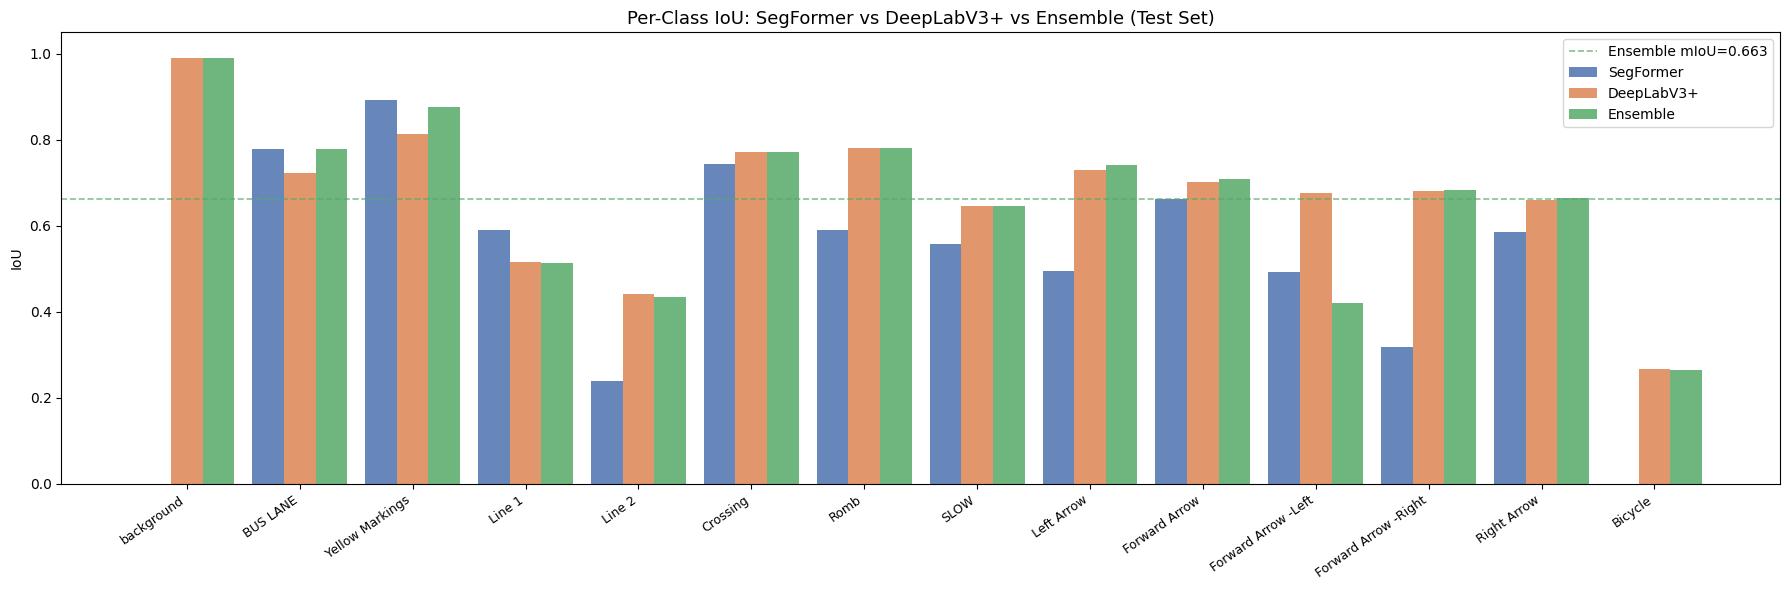

Chart saved → /content/drive/MyDrive/CVRoadMarkDetection/Ensemble/per_class_iou_comparison.png


In [13]:
x       = np.arange(NUM_CLASSES)
width   = 0.28
fig, ax = plt.subplots(figsize=(18, 6))

bars1 = ax.bar(x - width, np.nan_to_num(sf_test_iou),  width, label='SegFormer',   color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x,         np.nan_to_num(dl_test_iou),  width, label='DeepLabV3+',  color='#DD8452', alpha=0.85)
bars3 = ax.bar(x + width, np.nan_to_num(ens_test_iou), width, label='Ensemble',    color='#55A868', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('IoU')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class IoU: SegFormer vs DeepLabV3+ vs Ensemble (Test Set)', fontsize=13)
ax.legend()
ax.axhline(ens_test_miou, color='#55A868', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Ensemble mIoU={ens_test_miou:.3f}')
ax.legend()
plt.tight_layout()
save_path = os.path.join(ENSEMBLE_OUT, 'per_class_iou_comparison.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Chart saved → {save_path}')

## Step 14 — Visual Qualitative Comparison on a Few Test Images

  192 samples  [/content/drive/MyDrive/CVRoadMarkDetection/dataset/test/images]


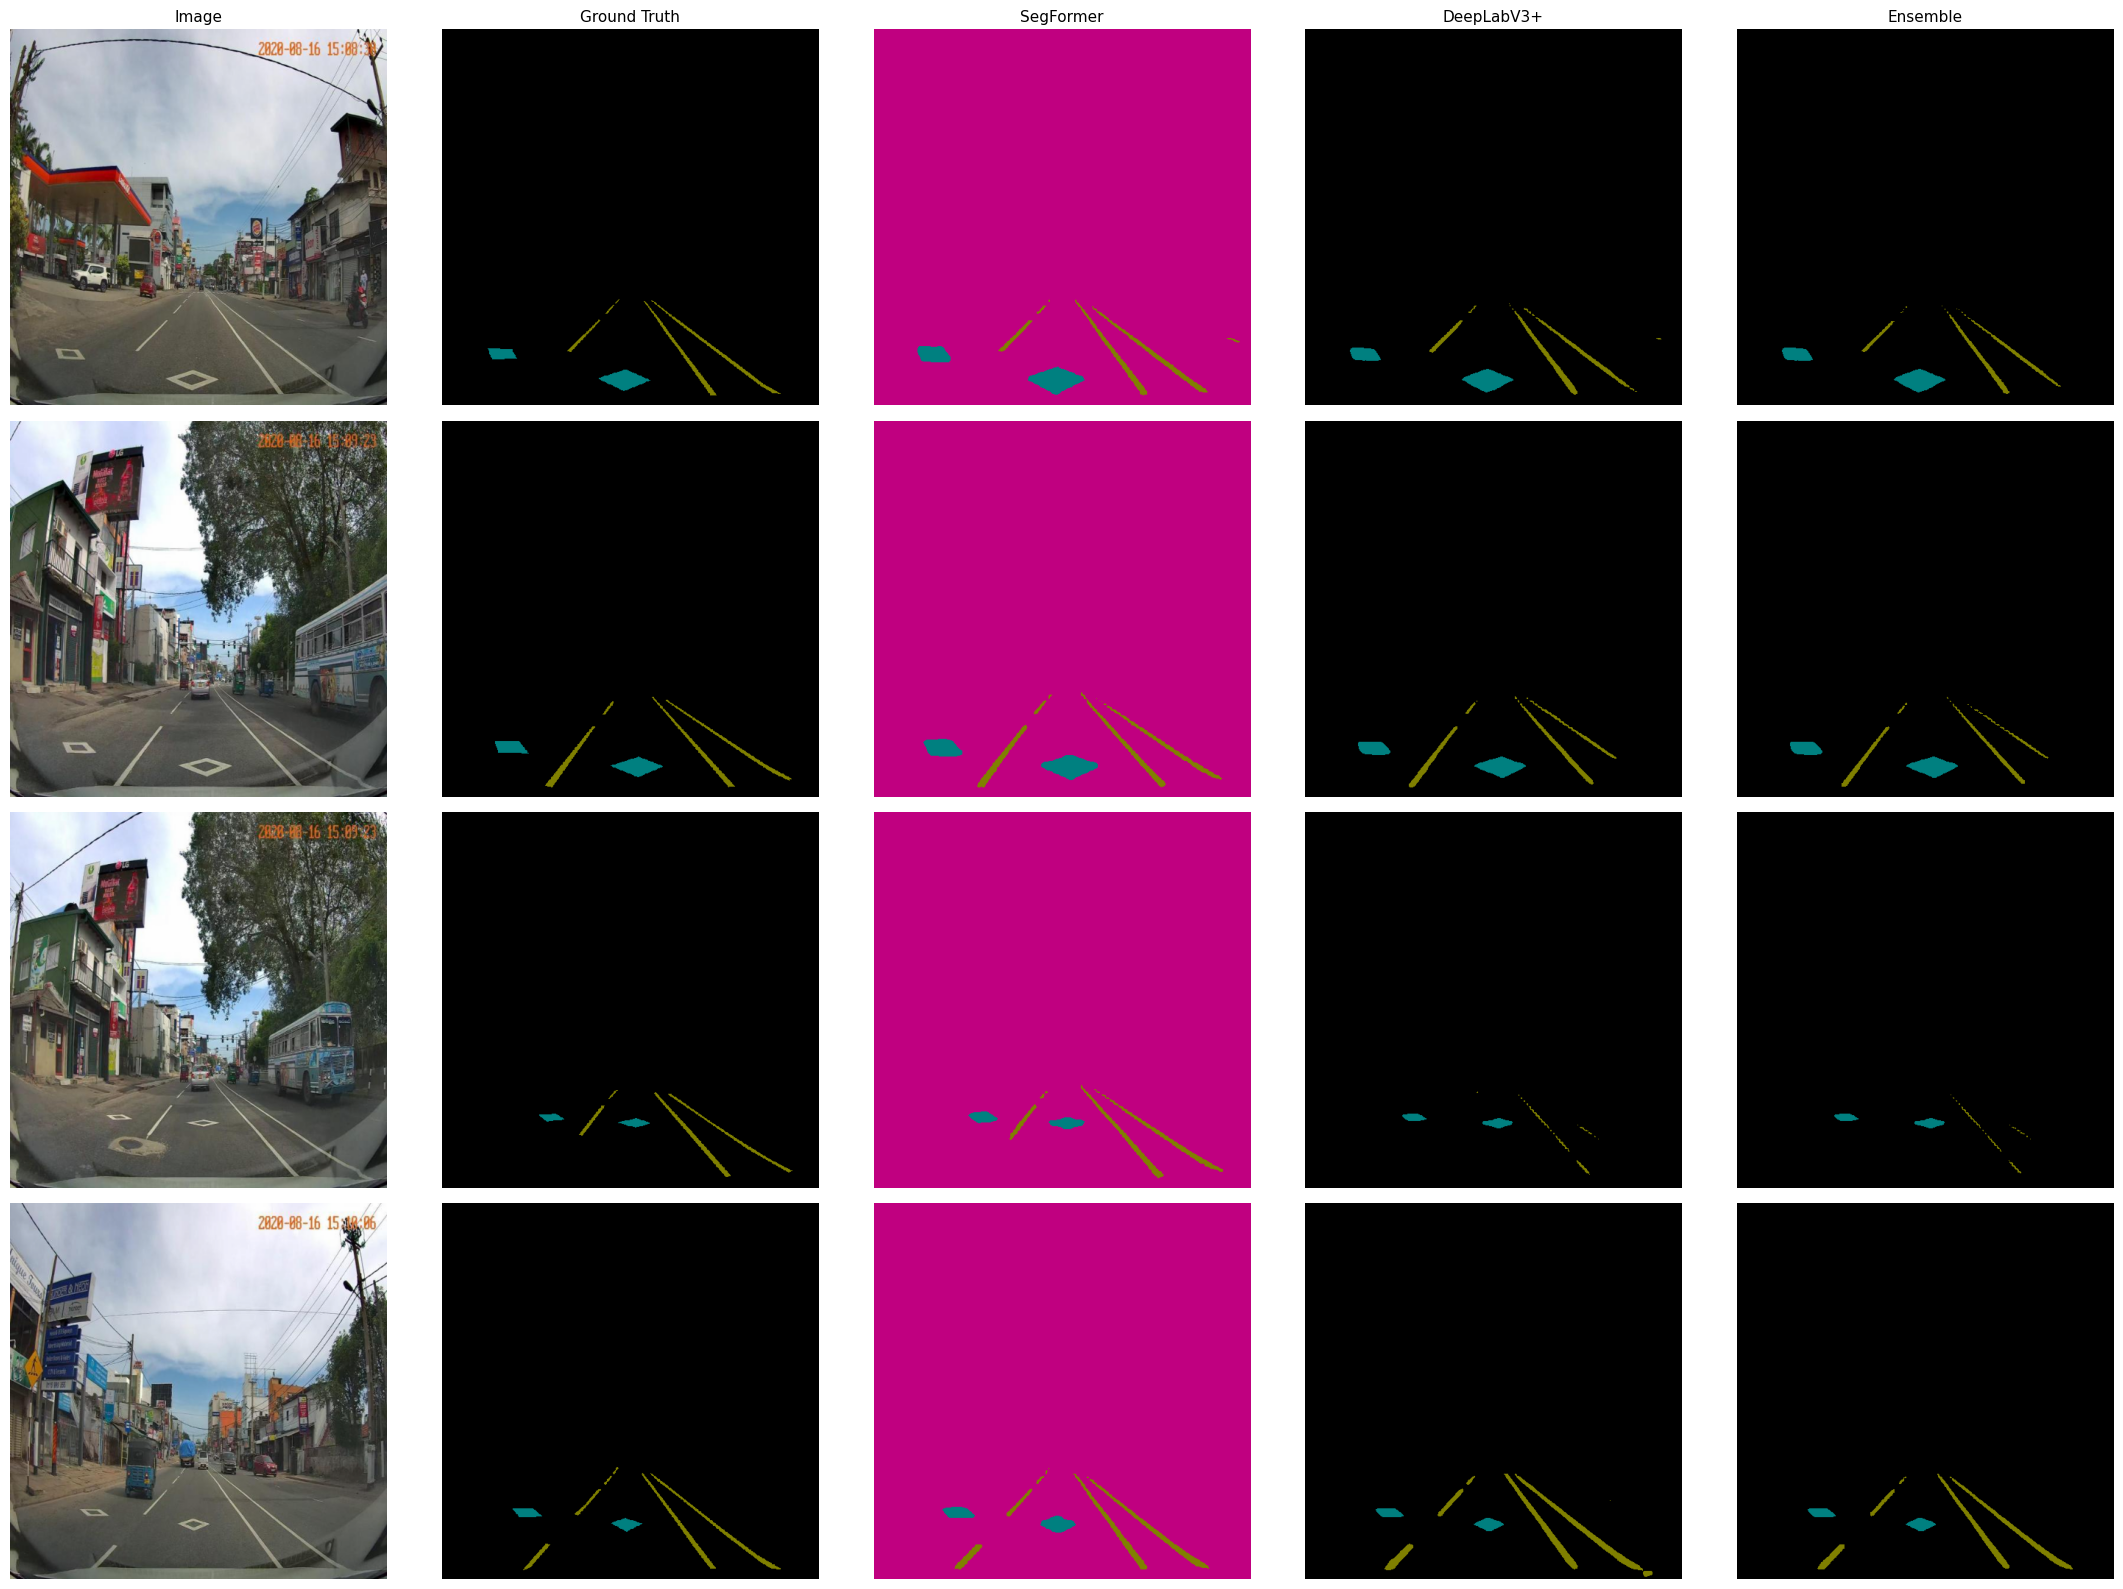

Visualisation saved → /content/drive/MyDrive/CVRoadMarkDetection/Ensemble/qualitative_comparison.png


In [14]:
# Colour palette for 14 classes
PALETTE = np.array([
    [  0,   0,   0],   # 0  background
    [128,   0,   0],   # 1  BUS LANE
    [  0, 128,   0],   # 2  Yellow Markings
    [128, 128,   0],   # 3  Line 1
    [  0,   0, 128],   # 4  Line 2
    [128,   0, 128],   # 5  Crossing
    [  0, 128, 128],   # 6  Romb
    [128, 128, 128],   # 7  SLOW
    [ 64,   0,   0],   # 8  Left Arrow
    [192,   0,   0],   # 9  Forward Arrow
    [ 64, 128,   0],   # 10 Forward Arrow -Left
    [192, 128,   0],   # 11 Forward Arrow -Right
    [ 64,   0, 128],   # 12 Right Arrow
    [192,   0, 128],   # 13 Bicycle
], dtype=np.uint8)

def mask_to_colour(mask_2d):
    """Convert a [H,W] class-id mask to an RGB image."""
    rgb = np.zeros((*mask_2d.shape, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_2d == c] = PALETTE[c]
    return rgb


MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denorm(tensor_chw):
    img = tensor_chw.permute(1, 2, 0).numpy() * STD + MEAN
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)


NUM_VIS = 4   # number of images to visualise
vis_ds  = RoadMarkDataset(TEST_IMG_DIR, MASK_DIR+'/test', val_tf)
vis_loader = DataLoader(vis_ds, 1, shuffle=False)

fig, axes = plt.subplots(NUM_VIS, 5, figsize=(22, NUM_VIS * 4))
titles = ['Image', 'Ground Truth', 'SegFormer', 'DeepLabV3+', 'Ensemble']
for ax, t in zip(axes[0], titles):
    ax.set_title(t, fontsize=11)

for row, (imgs, masks, stems) in enumerate(vis_loader):
    if row >= NUM_VIS: break
    imgs_dev = imgs.to(DEVICE)

    sf_log  = segformer_logits(segformer, imgs_dev).cpu()
    dl_log  = deeplab_logits(deeplab, imgs_dev).cpu()
    ens_log = ensemble_logits(imgs_dev, class_selector)

    img_rgb  = denorm(imgs[0])
    gt_rgb   = mask_to_colour(masks[0].numpy())
    sf_rgb   = mask_to_colour(sf_log.argmax(1)[0].numpy())
    dl_rgb   = mask_to_colour(dl_log.argmax(1)[0].numpy())
    ens_rgb  = mask_to_colour(ens_log.argmax(1)[0].numpy())

    for col, vis in enumerate([img_rgb, gt_rgb, sf_rgb, dl_rgb, ens_rgb]):
        axes[row][col].imshow(vis)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(stems[0], fontsize=8, rotation=0, labelpad=60, va='center')

plt.tight_layout()
vis_path = os.path.join(ENSEMBLE_OUT, 'qualitative_comparison.png')
plt.savefig(vis_path, dpi=120)
plt.show()
print(f'Visualisation saved → {vis_path}')

## Step 15 — Save Full Results to CSV

In [15]:
import csv

csv_path = os.path.join(ENSEMBLE_OUT, 'ensemble_results.csv')
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['class', 'segformer_val_iou', 'deeplab_val_iou', 'selector',
                     'segformer_test_iou', 'deeplab_test_iou', 'ensemble_test_iou'])
    for c in range(NUM_CLASSES):
        writer.writerow([
            CLASS_NAMES[c],
            f'{sf_val_iou[c]:.6f}'  if not np.isnan(sf_val_iou[c])  else '',
            f'{dl_val_iou[c]:.6f}'  if not np.isnan(dl_val_iou[c])  else '',
            'SegFormer' if class_selector[c] == 0 else 'DeepLabV3+',
            f'{sf_test_iou[c]:.6f}' if not np.isnan(sf_test_iou[c]) else '',
            f'{dl_test_iou[c]:.6f}' if not np.isnan(dl_test_iou[c]) else '',
            f'{ens_test_iou[c]:.6f}'if not np.isnan(ens_test_iou[c])else '',
        ])
    writer.writerow([
        'mIoU', f'{sf_val_miou:.6f}', f'{dl_val_miou:.6f}', '',
        f'{sf_test_miou:.6f}', f'{dl_test_miou:.6f}', f'{ens_test_miou:.6f}'
    ])

print(f'Results CSV saved → {csv_path}')
print(f'\n✅ Ensemble complete!')
print(f'   SegFormer mIoU  : {sf_test_miou:.4f}')
print(f'   DeepLabV3+ mIoU : {dl_test_miou:.4f}')
print(f'   Ensemble mIoU   : {ens_test_miou:.4f}  (+{ens_test_miou - max(sf_test_miou, dl_test_miou):+.4f} vs best single model)')

Results CSV saved → /content/drive/MyDrive/CVRoadMarkDetection/Ensemble/ensemble_results.csv

✅ Ensemble complete!
   SegFormer mIoU  : 0.4959
   DeepLabV3+ mIoU : 0.6716
   Ensemble mIoU   : 0.6628  (+-0.0088 vs best single model)


______________________________________________________________________________________________________________

In [17]:
# Path to your drone images
DRONE_IMG_DIR = '/content/drive/MyDrive/CVRoadMarkDetection/dronedataset'
DRONE_OUT_DIR = os.path.join(ENSEMBLE_OUT, 'drone_results')
os.makedirs(DRONE_OUT_DIR, exist_ok=True)

# Use the transformation defined in Step 4
inference_tf = val_tf

# Get list of images
drone_images = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
    drone_images.extend(list(Path(DRONE_IMG_DIR).glob(ext)))

print(f"Found {len(drone_images)} frames to process.")

Found 677 frames to process.


In [18]:
def run_ensemble_on_folder(image_paths, output_dir):
    segformer.eval()
    deeplab.eval()

    # Use the selector we calibrated in Step 9
    selector = class_selector

    for img_path in tqdm(image_paths, desc="Processing Frames"):
        # 1. Load and Transform
        orig_image = Image.open(img_path).convert('RGB')
        w, h = orig_image.size

        # Apply transforms (Resize, Normalize, ToTensor)
        input_tensor = inference_tf(image=np.array(orig_image))['image'].unsqueeze(0).to(DEVICE)

        # 2. Get Logits & Fuse
        with torch.no_grad():
            # Get upsampled logits from both
            sf_logits = segformer_logits(segformer, input_tensor)
            dl_logits = deeplab_logits(deeplab, input_tensor)

            # Convert to probabilities
            sf_prob = torch.softmax(sf_logits, dim=1).cpu()
            dl_prob = torch.softmax(dl_logits, dim=1).cpu()

            # Ensemble logic (channel-wise selection)
            sel_tensor = torch.tensor(selector).view(1, -1, 1, 1)
            fused_prob = (1.0 - sel_tensor) * sf_prob + sel_tensor * dl_prob

            # Get final prediction
            pred_mask = fused_prob.argmax(1).squeeze(0).numpy().astype(np.uint8)

        # 3. Post-Processing & Save
        # Resize mask back to original image size
        pred_mask_resized = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Create colored mask
        colored_mask = mask_to_colour(pred_mask_resized)

        # Create an overlay (blend original + mask)
        overlay = cv2.addWeighted(np.array(orig_image), 0.7, colored_mask, 0.3, 0)

        # Save results
        save_name = f"res_{img_path.stem}.png"
        Image.fromarray(overlay).save(os.path.join(output_dir, save_name))

run_ensemble_on_folder(drone_images, DRONE_OUT_DIR)
print(f"✅ Processing complete. Images saved to: {DRONE_OUT_DIR}")

Processing Frames: 100%|██████████| 677/677 [07:48<00:00,  1.45it/s]

✅ Processing complete. Images saved to: /content/drive/MyDrive/CVRoadMarkDetection/Ensemble/drone_results


In [19]:
import glob

def frames_to_video(img_folder, output_video_path, fps=30):
    images = sorted(glob.glob(os.path.join(img_folder, "res_*.png")))
    if not images: return

    frame = cv2.imread(images[0])
    height, width, layers = frame.shape
    video = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    for image in images:
        video.write(cv2.imread(image))

    video.release()
    print(f"Video saved to {output_video_path}")

frames_to_video(DRONE_OUT_DIR, os.path.join(ENSEMBLE_OUT, 'drone_inference_video.mp4'))

Video saved to /content/drive/MyDrive/CVRoadMarkDetection/Ensemble/drone_inference_video.mp4
